# Explainable Boosting Machines (EBM): Hands-on Tutorial

**Explainable Boosting Machines (EBM)** are tree-based Generalized Additive Models with Interactions ($\text{GA}^2\text{M}$) developed by Microsoft Research. They achieve predictive accuracy competitive with gradient-boosted trees (like XGBoost and LightGBM) while retaining exact, glass-box mathematical interpretability.

$$
g(\mathbb{E}[Y]) = \beta_0 + \sum_{i=1}^d f_i(x_i) + \sum_{(i, j) \in \mathcal{I}} f_{ij}(x_i, x_j)
$$

### In this notebook, you will learn:
1. **Data Preparation**: Loading and splitting the California Housing dataset.
2. **Baseline Benchmarking**: Comparing Linear Regression, Random Forest, and EBM on test metrics ($R^2$, RMSE, MAE).
3. **Training & FAST Interaction Detection**: Fitting univariate shape functions and high-scoring 2D interaction terms.
4. **Global Interpretability**: Extracting and plotting 1D feature shape curves and 2D interaction heatmaps.
5. **Local Exact Attribution**: Decomposing individual predictions into exact additive contributions.
6. **Model Debugging & Direct Editing**: Modifying internal lookup bins to enforce monotonicity and domain constraints.

## 0. Setup & Package Installation
Uncomment and run the cell below if `interpret` is not yet installed in your environment.

In [1]:
# !pip install interpret scikit-learn matplotlib seaborn pandas numpy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Dataset Loading & Exploration
We use the **California Housing** dataset (predicting median house value in units of $100k).

In [3]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 records:")
display(df.head())

print("\nSummary Statistics:")
display(df.describe().T[['mean', 'std', 'min', '50%', 'max']])

Dataset shape: (20640, 9)

First 5 records:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Summary Statistics:


,mean,std,min,50%,max
MedInc,3.870671,1.899822,0.499900,3.534800,15.000100
HouseAge,28.639486,12.585558,1.000000,29.000000,52.000000
AveRooms,5.429000,2.474173,0.846154,5.229129,141.909091
AveBedrms,1.096675,0.473911,0.333333,1.048780,34.066667
Population,1425.476744,1132.462122,3.000000,1166.000000,35682.000000
AveOccup,3.070655,10.386050,0.692308,2.818116,1243.333333
Latitude,35.631861,2.135952,32.540000,34.260000,41.950000
Longitude,-119.569704,2.003532,-124.350000,-118.490000,-114.310000
MedHouseVal,2.068558,1.153956,0.149990,1.797000,5.000010


In [4]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 16512 samples
Testing set:  4128 samples


## 2. Model Training & Comparative Benchmarking
Let's train three models:
1. **Ridge Regression** (Linear baseline - fully interpretable, low capacity)
2. **Random Forest Regressor** (Ensemble baseline - black-box, high capacity)
3. **Explainable Boosting Regressor (EBM)** (Glass-box $\text{GA}^2\text{M}$ - interpretable, high capacity)

In [5]:
# 1. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# 2. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 3. Explainable Boosting Regressor (EBM)
# interactions=10 instructs EBM to find top 10 pairwise interactions via FAST algorithm
ebm = ExplainableBoostingRegressor(
    interactions=10,
    max_bins=256,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
ebm.fit(X_train, y_train)

print("All models trained successfully!")

/opt/anaconda3/envs/xai/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/xai/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/xai/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


All models trained successfully!


In [6]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    return {'Model': name, 'R² Score': r2, 'RMSE': rmse, 'MAE': mae}

results = [
    evaluate_model('Ridge Regression (Linear)', ridge, X_test, y_test),
    evaluate_model('Explainable Boosting Machine (EBM)', ebm, X_test, y_test),
    evaluate_model('Random Forest (Black-box)', rf, X_test, y_test)
]

results_df = pd.DataFrame(results)
print("=== Test Set Performance Comparison ===")
display(results_df.style.highlight_max(subset=['R² Score'], color='#c8e6c9').highlight_min(subset=['RMSE', 'MAE'], color='#c8e6c9'))

=== Test Set Performance Comparison ===


/opt/anaconda3/envs/xai/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/xai/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/xai/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Model,R² Score,RMSE,MAE
0,Ridge Regression (Linear),0.575855,0.745522,0.533204
1,Explainable Boosting Machine (EBM),0.833205,0.467514,0.317102
2,Random Forest (Black-box),0.802508,0.508720,0.330831


## 3. Global Interpretability: Inspecting Learned Shape Functions

Because an EBM decomposes the target into additive 1D and 2D terms, we can directly plot:
- **1D Shape Curves $f_i(x_i)$**: The marginal impact of a single feature on predicted price.
- **2D Interaction Heatmaps $f_{ij}(x_i, x_j)$**: Pure pairwise effects discovered by the FAST algorithm.

In [7]:
# Inspect feature names and identified interaction terms
for idx, name in enumerate(ebm.term_names_):
    term_type = "Interaction (2D)" if " & " in name else "Main Effect (1D)"
    print(f"Term {idx:02d}: {name:<35} [{term_type}]")

Term 00: MedInc                              [Main Effect (1D)]
Term 01: HouseAge                            [Main Effect (1D)]
Term 02: AveRooms                            [Main Effect (1D)]
Term 03: AveBedrms                           [Main Effect (1D)]
Term 04: Population                          [Main Effect (1D)]
Term 05: AveOccup                            [Main Effect (1D)]
Term 06: Latitude                            [Main Effect (1D)]
Term 07: Longitude                           [Main Effect (1D)]
Term 08: MedInc & HouseAge                   [Interaction (2D)]
Term 09: MedInc & Population                 [Interaction (2D)]
Term 10: MedInc & AveOccup                   [Interaction (2D)]
Term 11: MedInc & Longitude                  [Interaction (2D)]
Term 12: HouseAge & AveOccup                 [Interaction (2D)]
Term 13: AveBedrms & Longitude               [Interaction (2D)]
Term 14: Population & AveOccup               [Interaction (2D)]
Term 15: AveOccup & Latitude            

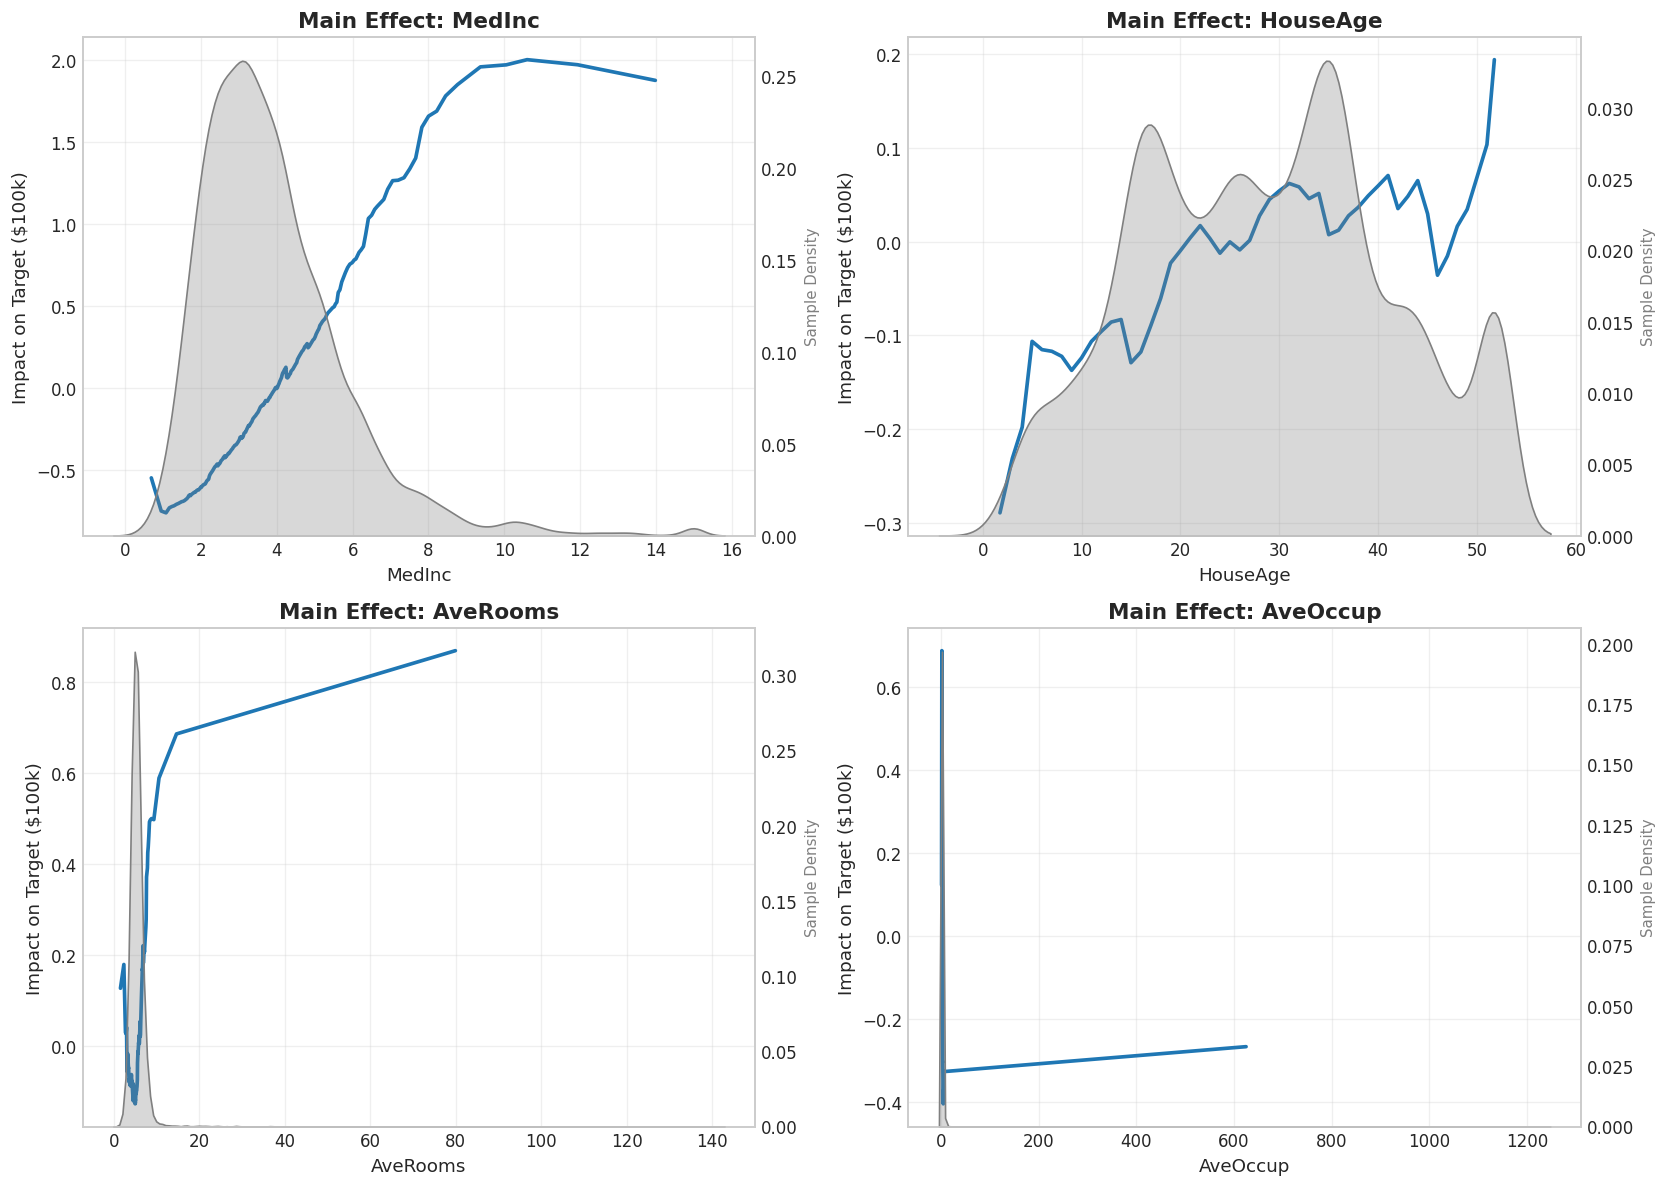

In [12]:
# Plotting key 1D shape functions
features_to_plot = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

ebm_global = ebm.explain_global(name='EBM Global Explanation')

for ax, feat in zip(axes, features_to_plot):
    idx = ebm.term_names_.index(feat)
    data = ebm_global.data(idx)
    
    bin_edges = np.array(data['names'])
    scores = np.array(data['scores'])
    
    # Compute bin midpoints to match N scores with N+1 edges
    if len(bin_edges) == len(scores) + 1:
        x_plot = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    else:
        min_len = min(len(bin_edges), len(scores))
        x_plot = bin_edges[:min_len]
        scores = scores[:min_len]
    
    # Main effect shape curve
    ax.plot(x_plot, scores, color='#1f77b4', lw=2.2, label='Learned $f(x)$')
    ax.set_title(f'Main Effect: {feat}', fontsize=13, fontweight='bold')
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('Impact on Target ($100k)', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Overlay sample density
    ax2 = ax.twinx()
    sns.kdeplot(X_train[feat], ax=ax2, color='gray', alpha=0.3, fill=True)
    ax2.set_ylabel('Sample Density', color='gray', fontsize=9)
    ax2.grid(False)

plt.tight_layout()
plt.show()

### Visualizing a 2D FAST Interaction Term
Let's visualize the learned geographic interaction between `Latitude` and `Longitude`.

Displaying 2D Interaction for: Latitude & Longitude


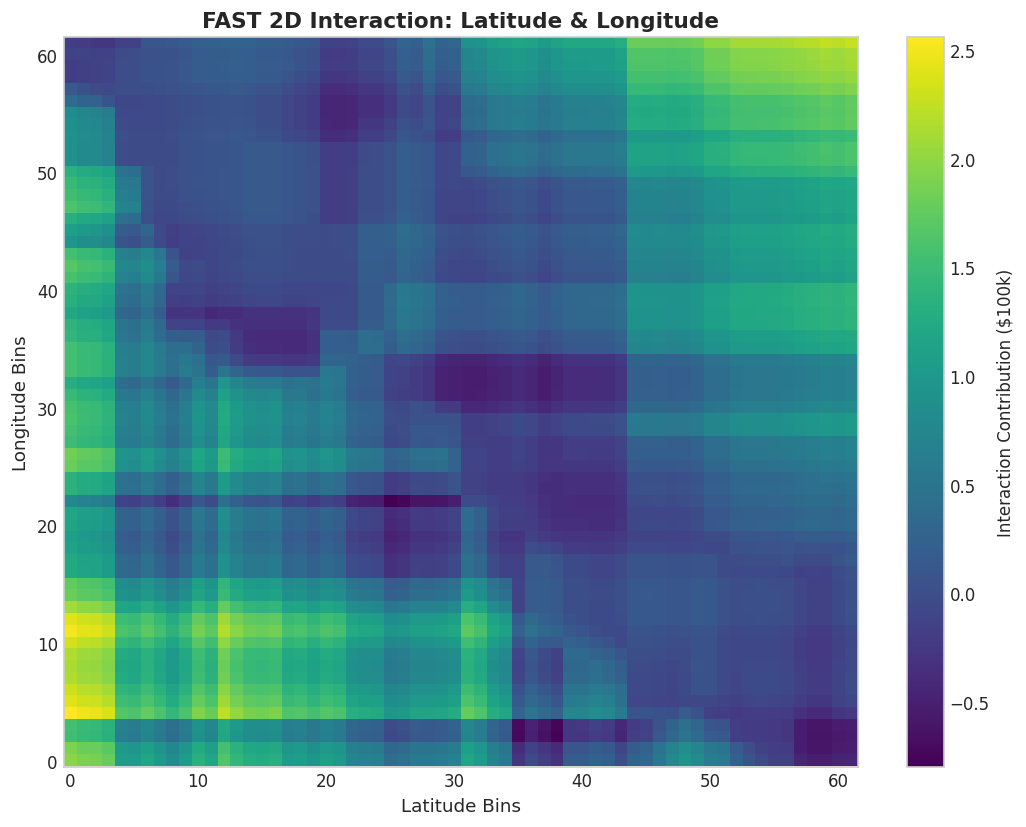

In [14]:
# Visualizing 2D FAST interaction term
lat_long_term = [t for t in ebm.term_names_ if 'Latitude' in t and 'Longitude' in t]

if lat_long_term:
    term_idx = ebm.term_names_.index(lat_long_term[0])
    print(f"Displaying 2D Interaction for: {lat_long_term[0]}")
    
    ebm_global = ebm.explain_global(name='EBM Global Explanation')
    
    # 1. Matplotlib Heatmap (guaranteed rendering in all Jupyter / VS Code environments)
    data_2d = ebm_global.data(term_idx)
    scores_2d = np.array(data_2d['scores'])
    
    plt.figure(figsize=(9, 7))
    im = plt.imshow(scores_2d.T, origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar(im, label='Interaction Contribution ($100k)')
    plt.title(f'FAST 2D Interaction: {lat_long_term[0]}', fontsize=13, fontweight='bold')
    plt.xlabel('Latitude Bins', fontsize=11)
    plt.ylabel('Longitude Bins', fontsize=11)
    plt.grid(False)
    plt.tight_layout()
    plt.show()
    
    # 2. Interactive Plotly Figure (call directly or pass ebm_global to show)
    # Option A: display(ebm_global.visualize(term_idx))
    # Option B: show(ebm_global, term_idx)
    display(ebm_global.visualize(term_idx))
else:
    print("Latitude & Longitude was not in the top-ranked interaction list for this run.")

## 4. Local Interpretability: Exact Additive Scoring

Unlike SHAP or LIME which approximate feature attribution via sampling perturbations, EBM provides **exact, deterministic additive attribution**:

$$\hat{y}(x^*) = \beta_0 + \sum_{i=1}^d f_i(x_i^*) + \sum_{(i,j) \in \mathcal{I}} f_{ij}(x_i^*, x_j^*)$$

In [16]:
# Pick a test house sample
sample_idx = 10
sample = X_test.iloc[sample_idx:sample_idx+1]
actual_val = y_test.iloc[sample_idx]
predicted_val = ebm.predict(sample)[0]

print(f"Sample #{sample_idx}")
print(f"Actual House Value:    ${actual_val * 100000:,.2f}")
print(f"Predicted House Value: ${predicted_val * 100000:,.2f}")
print(f"Base Intercept (β₀):   ${ebm.intercept_ * 100000:,.2f}")

Sample #10
Actual House Value:    $123,200.00
Predicted House Value: $103,597.12
Base Intercept (β₀):   $207,194.69


In [17]:
# Explain the local sample
ebm_local = ebm.explain_local(sample, y_test.iloc[sample_idx:sample_idx+1])
local_data = ebm_local.data(0)

# Build waterfall breakdown DataFrame
decomp_df = pd.DataFrame({
    'Term': local_data['names'],
    'Feature Value': [f"{v:.3f}" if isinstance(v, (int, float)) else str(v) for v in local_data['values']],
    'Contribution ($100k)': local_data['scores']
}).sort_values(by='Contribution ($100k)', ascending=False)

# Verify exact additivity mathematically
sum_contributions = np.sum(local_data['scores']) + ebm.intercept_
print(f"Sum of intercept + all terms: {sum_contributions:.5f}")
print(f"Direct model output:          {predicted_val:.5f}")
print(f"Exact match: {np.isclose(sum_contributions, predicted_val)}\n")

display(decomp_df.head(10))

Sum of intercept + all terms: 1.03597
Direct model output:          1.03597
Exact match: True



,Term,Feature Value,Contribution ($100k)
17,Latitude & Longitude,,0.331239
7,Longitude,-120.370,0.311005
9,MedInc & Population,,0.134783
3,AveBedrms,1.172,0.096144
5,AveOccup,2.602,0.067588
1,HouseAge,30.000,0.054147
11,MedInc & Longitude,,0.011872
15,AveOccup & Latitude,,0.003912
8,MedInc & HouseAge,,-0.000353
12,HouseAge & AveOccup,,-0.004912


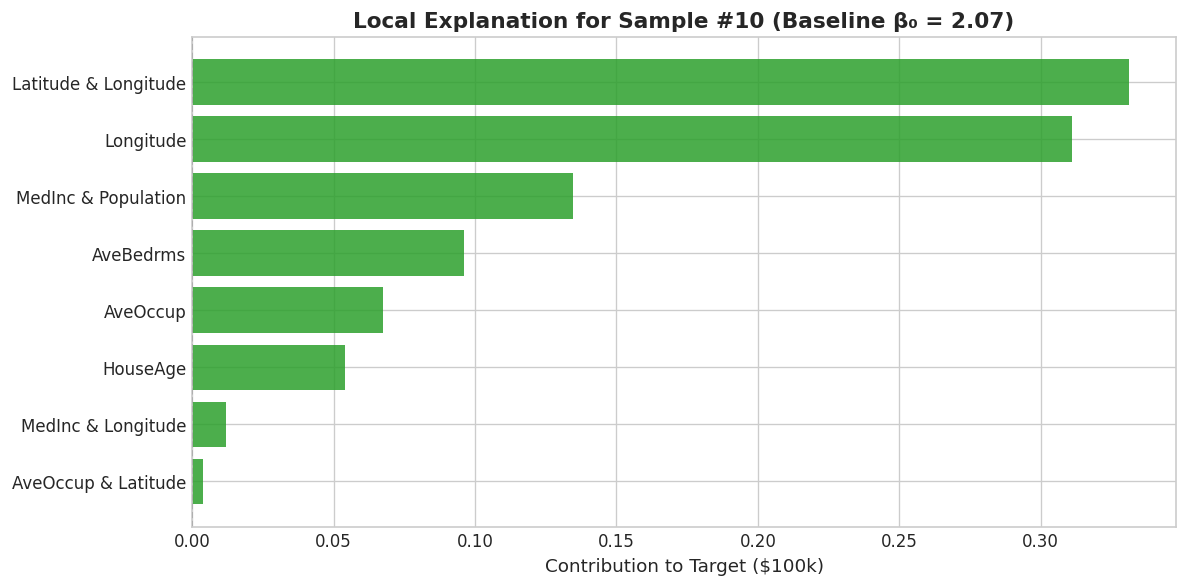

In [18]:
# Plotting Local Explanation (Waterfall chart)
top_terms = decomp_df.head(8).copy()

plt.figure(figsize=(10, 5))
colors = ['#2ca02c' if s >= 0 else '#d62728' for s in top_terms['Contribution ($100k)']]
plt.barh(top_terms['Term'], top_terms['Contribution ($100k)'], color=colors, alpha=0.85)
plt.axvline(0, color='black', lw=1, ls='--')
plt.title(f'Local Explanation for Sample #{sample_idx} (Baseline β₀ = {ebm.intercept_:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Contribution to Target ($100k)', fontsize=11)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Model Auditing & Direct Model Editing

One of the unique superpowers of EBMs is **direct editability**. If domain experts determine that a specific region of a shape curve exhibits an unnatural spike (e.g., due to data leakage or sparse outliers), practitioners can directly modify the score array without retraining.

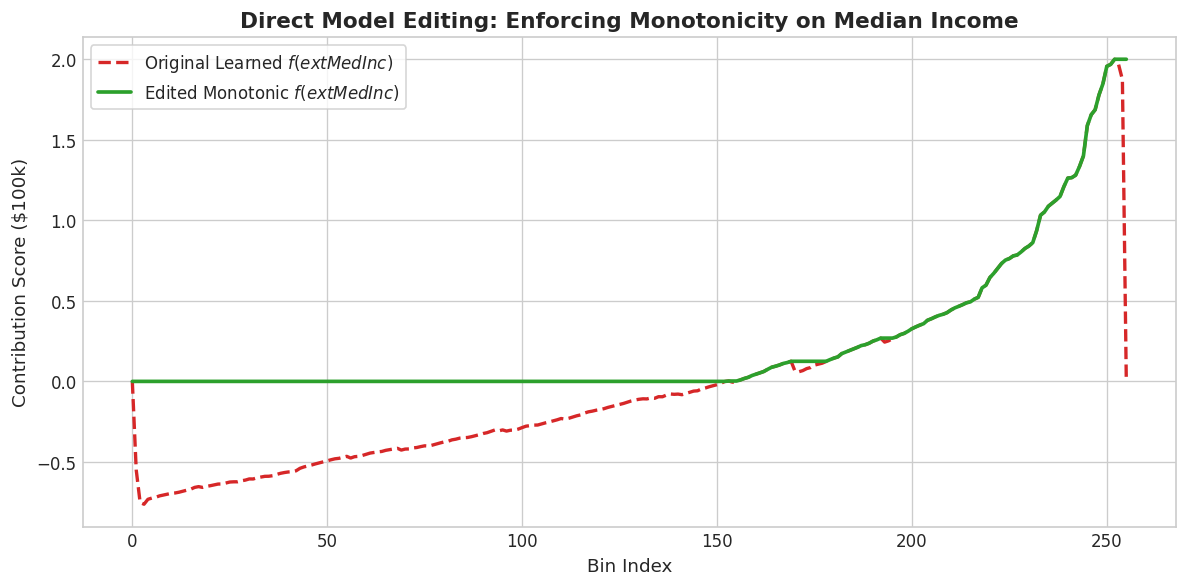

In [19]:
# Clone EBM parameters for editing
import copy
ebm_edited = copy.deepcopy(ebm)

# Enforce monotonicity constraint on MedInc (higher income should never decrease house valuation)
medinc_idx = ebm_edited.term_names_.index('MedInc')
original_scores = ebm_edited.term_scores_[medinc_idx].copy()

# Apply monotonic cumulative maximum
monotonic_scores = np.maximum.accumulate(original_scores)
ebm_edited.term_scores_[medinc_idx] = monotonic_scores

# Compare before & after
plt.figure(figsize=(10, 5))
plt.plot(original_scores, label='Original Learned $f(\text{MedInc})$', color='#d62728', lw=2, ls='--')
plt.plot(monotonic_scores, label='Edited Monotonic $f(\text{MedInc})$', color='#2ca02c', lw=2.2)
plt.title('Direct Model Editing: Enforcing Monotonicity on Median Income', fontsize=13, fontweight='bold')
plt.xlabel('Bin Index', fontsize=11)
plt.ylabel('Contribution Score ($100k)', fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [20]:
# Verify edited model performance
orig_r2 = r2_score(y_test, ebm.predict(X_test))
edited_r2 = r2_score(y_test, ebm_edited.predict(X_test))

print(f"Original EBM Test R²: {orig_r2:.4f}")
print(f"Edited EBM Test R²:   {edited_r2:.4f}")
print(f"Difference:           {edited_r2 - orig_r2:+.5f}")

Original EBM Test R²: 0.8332
Edited EBM Test R²:   0.7469
Difference:           -0.08631


## 6. Summary & Key Takeaways

| Feature / Aspect | Linear Models | Standard GBDT (XGBoost/LightGBM) | Explainable Boosting Machine (EBM) |
| :--- | :--- | :--- | :--- |
| **Accuracy** | Low (underfits non-linearities) | Very High | **Very High** (matches GBDT on tabular data) |
| **Interpretability** | Global coefficients only | Black-box (requires post-hoc SHAP) | **Native Glass-Box** (1D curves + 2D interaction grids) |
| **Local Attribution** | Exact | Approximated (Sampling variance) | **Exact** ($\hat{y} = \beta_0 + \sum f_i + \sum f_{ij}$) |
| **Interaction Handling**| Manual feature engineering | Opaque high-order interactions | **Screened & Ranked via FAST** |
| **Post-hoc Editability**| Weights only | Impossible without retraining | **Directly editable bin tables** |